# Unaligned Evaluation - Fix Shifted (SMC 2026 Paper)

In our implementation, **unaligned evaluation** means:

| Profile | Shifts (seconds) | #Points | Purpose |
|---|---|---:|---|
| `--fast` | `0, ±0.1` | 3 | Quick debug check |
| `--coarse` | `0, ±0.1, ±0.2, ±0.5` | 7 | Low-cost robustness check |
| `--kim_full` | `0, ±0.1, ±0.2, ±0.3, ±0.4, ±0.5, ±1.0, ±1.5, ±2.0, ±2.5` | 19 | Full Kim and Serra (ISMIR2024) sweep, also our paper |

### Why our `shifted` mode is the correct evaluation mode

If MIDI score is shifted to use in inference, then post-processing and scoring must use the **same shifted score timeline**. <br>

### Problem in kim ismir2024 - it mixes two timelines
1. Inference uses **shifted** score (shifted ground truth).
2. Post-processing and scoring use **unshifted** score (unshifted ground truth).

This mismatch can make valid model behavior look wrong and can artificially degrade results.

### Correct behavior in our `shifted` mode
`shifted` mode keeps one consistent timeline:
1. Inference uses shifted score.
2. Post-processing pick uses shifted onset/frame.
3. Evaluation target is shifted in the same way.

This is internally consistent and musically meaningful.

---

## Practical implication

- `reference` can report overly poor performance under score shift (timeline mismatch effect).
- `shifted` gives a fair measure of how well the model works under that shifted score condition.
- For score-shift experiments in our pipeline, use:

`--fix_shifted`

---

### After the experiment done, we plot the summary plots and report these "shifted" MAE & STD result in the SMC paper.

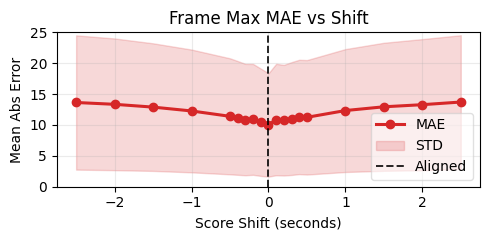

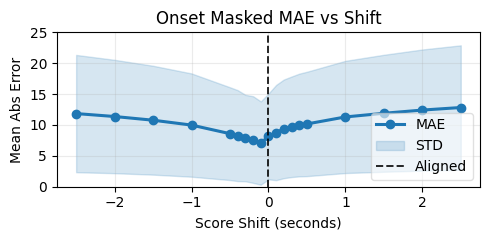

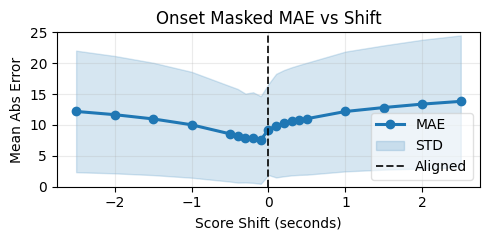

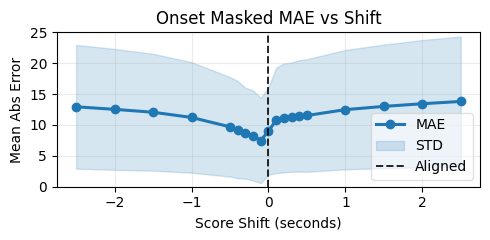

In [ ]:
import sys
sys.path.insert(0, "/media/datadisk/home/22828187/zhanh/202601_midisemi/score_hpt/pytorch")
import importlib
import pytorch.calculate_scores_unaligned as csu
importlib.reload(csu)

csv_path_film = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/FiLMUNetPretrained+frame/1000000_iterations/FiLMUNetPretrained+frame_smd_kim_full_shifted_unaligned_summary.csv"
csv_path_hpt = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/hpt+onset+frame+score_note_editor/20000_iterations/hpt+onset+frame+score_note_editor_smd_kim_full_shifted_unaligned_summary.csv"
csv_path_hppnet = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/hppnet+onset+frame+score_note_editor/20000_iterations/hppnet+onset+frame+score_note_editor_smd_kim_full_shifted_unaligned_summary.csv"
csv_path_dynest="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/dynest+onset+frame+score_note_editor/20000_iterations/dynest+onset+frame+score_note_editor_smd_kim_full_shifted_unaligned_summary.csv"

csu.plot_unaligned_summary_csv(csv_path=csv_path_film,
    metric="frame_max", color="#d62728", size=(5, 2.7), y_max_axis=25)
csu.plot_unaligned_summary_csv(csv_path=csv_path_hpt,
    metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)
csu.plot_unaligned_summary_csv(csv_path=csv_path_hppnet,
    metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)
csu.plot_unaligned_summary_csv(csv_path=csv_path_dynest,
    metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)

# csu.plot_unaligned_summary_csv(csv_path=csv_path_film,
#     metric="mir_eval_recall", color="#ff7f0e", size=(5, 2.7), y_max_axis=0.85)
# csu.plot_unaligned_summary_csv(csv_path=csv_path_hpt,
#     metric="mir_eval_recall", color="#ff7f0e", size=(5, 2.7), y_max_axis=0.85)
# csu.plot_unaligned_summary_csv(csv_path=csv_path_hppnet,
#     metric="mir_eval_recall", color="#ff7f0e", size=(5, 2.7), y_max_axis=0.85)
# csu.plot_unaligned_summary_csv(csv_path=csv_path_dynest,
#     metric="mir_eval_recall", color="#ff7f0e", size=(5, 2.7), y_max_axis=0.85)


## Unaligned Test - Experiment run here
1. FiLM-UNet
2. Score-Transformer + HPT / HPPNet / DynEst

In [11]:
!python pytorch/calculate_scores_unaligned.py --kim_full --enable_mireval --fix_shifted \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=filmunet_pretrained \
  model.kim_condition=frame \
  model.frontend_pretrained="/media/datadisk/home/22828187/zhanh/202510_hpt_smc/other repos/kim_ismir2024/pretrained/FiLMUNetPretrained+frame/1000000_iterations.pth" \
  feature.audio_feature=logmel feature.sample_rate=16000 feature.segment_seconds=2.0 feature.hop_seconds=1.0 feature.frames_per_second=100

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : FiLMUNetPretrained+frame
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_smc/other repos/kim_ismir2024/pretrained/FiLMUNetPretrained+frame/1000000_iterations.pth
Params          : 8797563 (8.798 M)
Shifts (sec)    : [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -1.0, -1.5, -2.0, -2.5, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : shifted
Enable MirEval  : True
Kim Unaligned Eval: 100%|██████████████| 49/49 [59:20<00:00, 72.66s/file, shift0_frame_err=9.96]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim

In [12]:
!python pytorch/calculate_scores_unaligned.py --kim_full --enable_mireval --fix_shifted \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=hpt \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.frontend_pretrained="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hpt+onset+frame+score_note_editor/20000_iterations.pth"

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : hpt+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hpt+onset+frame+score_note_editor/20000_iterations.pth
Params          : 5043529 (5.044 M)
Shifts (sec)    : [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -1.0, -1.5, -2.0, -2.5, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : shifted
Enable MirEval  : True
Kim Unaligned Eval: 100%|█████████████| 49/49 [38:00<00:00, 46.54s/file, shift0_frame_err=15.83]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/

In [13]:
!python pytorch/calculate_scores_unaligned.py --kim_full --enable_mireval --fix_shifted \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=hppnet \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.frontend_pretrained="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hppnet+onset+frame+score_note_editor/20000_iterations.pth"

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : hppnet+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hppnet+onset+frame+score_note_editor/20000_iterations.pth
Params          : 1488450 (1.488 M)
Shifts (sec)    : [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -1.0, -1.5, -2.0, -2.5, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : shifted
Enable MirEval  : True
Kim Unaligned Eval: 100%|█████████████| 49/49 [29:55<00:00, 36.64s/file, shift0_frame_err=16.81]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/works

In [14]:
!python pytorch/calculate_scores_unaligned.py --kim_full --enable_mireval --fix_shifted \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=dynest \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.frontend_pretrained="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/dynest+onset+frame+score_note_editor/20000_iterations.pth"

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : dynest+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/dynest+onset+frame+score_note_editor/20000_iterations.pth
Params          : 14267481 (14.267 M)
Shifts (sec)    : [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -1.0, -1.5, -2.0, -2.5, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : shifted
Enable MirEval  : True
Kim Unaligned Eval: 100%|█████████████| 49/49 [22:49<00:00, 27.95s/file, shift0_frame_err=17.71]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/wor

### The following Recall_10% results is for PhD Thesis, not in SMC 2026 Paper.

Some notes:
- The Recall_10% is used in my PhD Thesis, not in published paper. 
- Specifically, it comes from the mir_eval, different with the normal "Recall" used in FiLM-UNet paper (Kim and Serra, ismir2024).
- P/R/F1 from mir_eval is same, because we post-processing the VeloEst with the ground truth MIDI notes. No timing estimated errors, so P=R=F1.

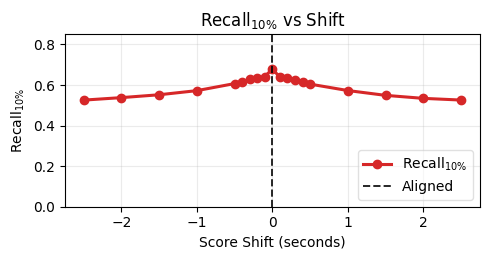

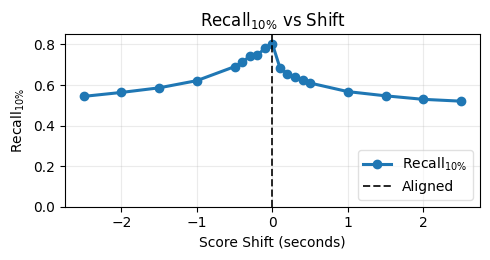

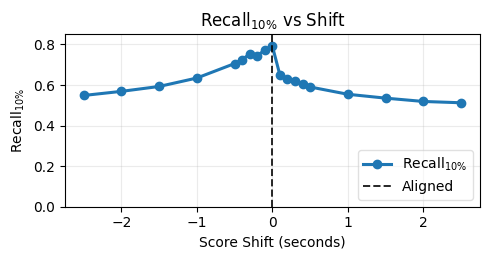

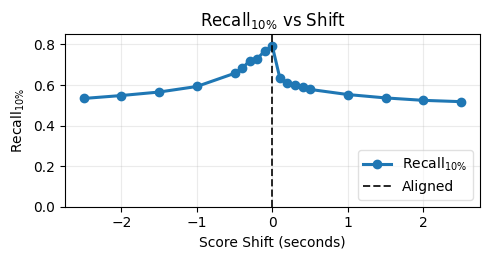

In [16]:
import sys
sys.path.insert(0, "/media/datadisk/home/22828187/zhanh/202601_midisemi/score_hpt/pytorch")
import importlib
import pytorch.calculate_scores_unaligned as csu
importlib.reload(csu)

csv_path_film = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/FiLMUNetPretrained+frame/1000000_iterations/FiLMUNetPretrained+frame_smd_kim_full_shifted_unaligned_summary.csv"
csv_path_hpt = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/hpt+onset+frame+score_note_editor/20000_iterations/hpt+onset+frame+score_note_editor_smd_kim_full_shifted_unaligned_summary.csv"
csv_path_hppnet = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/hppnet+onset+frame+score_note_editor/20000_iterations/hppnet+onset+frame+score_note_editor_smd_kim_full_shifted_unaligned_summary.csv"
csv_path_dynest="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned/smd/dynest+onset+frame+score_note_editor/20000_iterations/dynest+onset+frame+score_note_editor_smd_kim_full_shifted_unaligned_summary.csv"

# csu.plot_unaligned_summary_csv(csv_path=csv_path_film,
#     metric="frame_max", color="#d62728", size=(5, 2.7), y_max_axis=25)
# csu.plot_unaligned_summary_csv(csv_path=csv_path_hpt,
#     metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)
# csu.plot_unaligned_summary_csv(csv_path=csv_path_hppnet,
#     metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)
# csu.plot_unaligned_summary_csv(csv_path=csv_path_dynest,
#     metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)

csu.plot_unaligned_summary_csv(csv_path=csv_path_film,
    metric="mir_eval_recall", color="#d62728", size=(5, 2.7), y_max_axis=0.85) # #ff7f0e
csu.plot_unaligned_summary_csv(csv_path=csv_path_hpt,
    metric="mir_eval_recall", color="#1f77b4", size=(5, 2.7), y_max_axis=0.85)
csu.plot_unaligned_summary_csv(csv_path=csv_path_hppnet,
    metric="mir_eval_recall", color="#1f77b4", size=(5, 2.7), y_max_axis=0.85)
csu.plot_unaligned_summary_csv(csv_path=csv_path_dynest,
    metric="mir_eval_recall", color="#1f77b4", size=(5, 2.7), y_max_axis=0.85)


# Unaligned Evaluation - Random Shift (PhD Thesis Addons)

Scope: PhD Thesis vs. SMC Paper
- **SMC Paper:** Only reports "Fix Shifted" (`shifted`) results to show absolute, controlled shift bounds.
- **PhD Thesis:** We add `random_shifted` results. This simulates real-world, unpredictable misalignments.


In our implementation, **random shift evaluation** means:

| Profile | Max Shift Boundary (seconds) | Sampling Pool | Purpose |
|---|---|---|---|
| `--fast` | `0.1` | `0, ±0.1` | Quick debug check |
| `--coarse` | `0.5` | `0, ±0.1, ±0.2, ..., ±0.5` | Low-cost robustness check |
| `--kim_full` | `2.5` | `0, ±0.1, ±0.2, ..., ±2.5` | Full sweep for the thesis |

---

## How "Random Shifted" works

Unlike the fixed `shifted` mode where one exact shift is applied universally, `random_shifted` uses the profile values as **maximum boundaries**.

1. **Absolute Bounds:** The evaluation profile sets a maximum limit (e.g., `0.5s`).
2. **Dynamic Sampling:** For *every single piece* in the test set, the script randomly picks a shift magnitude in `0.1s` increments up to that boundary (e.g., `0.1, 0.2, 0.3, 0.4, 0.5`).
3. **Randomized Direction:** A random sign (`+` or `-`) is applied to the sampled magnitude.

---

## Why we need Random Shift for the thesis

While fixed shifts prove the model handles specific misalignments, real-world expressive transcription faces messy, inconsistent data.

1. **Simulates Real-World:** Misalignment in real human performances is rarely a constant global shift. Random shift mimics this unpredictable noise.
2. **Tests Generalization:** Proves the model's robustness is a generalized resilience, not an artifact of a single fixed timeline shift.
3. **Consistent Evaluation:** Like our `shifted` mode, it correctly keeps inference, post-processing, and evaluation targets on the same timeline.

---

## Practical implication

- Running this mode saves results to `kim_eval_unaligned_random` so it does not overwrite the fixed-shift SMC results.
- For random score-shift experiments in the thesis pipeline, use:

`--random_shifted`

In [10]:
!python pytorch/calculate_scores_unaligned.py --kim_full --enable_mireval --random_shifted \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=filmunet_pretrained \
  model.kim_condition=frame \
  model.frontend_pretrained="/media/datadisk/home/22828187/zhanh/202510_hpt_smc/other repos/kim_ismir2024/pretrained/FiLMUNetPretrained+frame/1000000_iterations.pth" \
  feature.audio_feature=logmel feature.sample_rate=16000 feature.segment_seconds=2.0 feature.hop_seconds=1.0 feature.frames_per_second=100

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : FiLMUNetPretrained+frame
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_smc/other repos/kim_ismir2024/pretrained/FiLMUNetPretrained+frame/1000000_iterations.pth
Params          : 8797563 (8.798 M)
Shift Ranges (sec): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : random_shifted
Enable MirEval  : True
Kim Unaligned Eval: 100%|██████████████| 49/49 [33:18<00:00, 40.79s/file, shift0_frame_err=9.96]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned_random/smd/FiLMUNetPretrained

In [7]:
!python pytorch/calculate_scores_unaligned.py --kim_full --enable_mireval --random_shifted \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=hpt \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.frontend_pretrained="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hpt+onset+frame+score_note_editor/20000_iterations.pth"

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : hpt+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hpt+onset+frame+score_note_editor/20000_iterations.pth
Params          : 5043529 (5.044 M)
Shift Ranges (sec): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : random_shifted
Enable MirEval  : True
Kim Unaligned Eval: 100%|█████████████| 49/49 [21:50<00:00, 26.75s/file, shift0_frame_err=15.83]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned_random/smd/hpt+onset+frame

In [8]:
!python pytorch/calculate_scores_unaligned.py --kim_full --enable_mireval --random_shifted \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=hppnet \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.frontend_pretrained="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hppnet+onset+frame+score_note_editor/20000_iterations.pth"

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : hppnet+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/hppnet+onset+frame+score_note_editor/20000_iterations.pth
Params          : 1488450 (1.488 M)
Shift Ranges (sec): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : random_shifted
Enable MirEval  : True
Kim Unaligned Eval: 100%|█████████████| 49/49 [17:55<00:00, 21.94s/file, shift0_frame_err=16.81]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned_random/smd/hppnet+on

In [9]:
!python pytorch/calculate_scores_unaligned.py --kim_full --enable_mireval --random_shifted \
  exp.run_infer=single \
  dataset.test_set=smd \
  model.type=dynest \
  score_informed.method=note_editor \
  model.input2=onset model.input3=frame \
  model.frontend_pretrained="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/dynest+onset+frame+score_note_editor/20000_iterations.pth"

/media/datadisk/home/22828187/conda_env/miniconda3/envs/bark_env/lib/python3.10/site-packages/nnAudio/Spectrogram.py:4: Warning: importing Spectrogram subpackage will be deprecated soon. You should import the feature extractor from the feature subpackage. See actual documentation.
  warnings.warn(
Evaluation Mode : Kim-style Unaligned (single checkpoint)
Model Name      : dynest+onset+frame+score_note_editor
Test Set        : smd
Checkpoint      : /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/checkpoints/dynest+onset+frame+score_note_editor/20000_iterations.pth
Params          : 14267481 (14.267 M)
Shift Ranges (sec): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 2.5]
Shift Profile   : kim_full
Eval Target     : random_shifted
Enable MirEval  : True
Kim Unaligned Eval: 100%|█████████████| 49/49 [14:14<00:00, 17.43s/file, shift0_frame_err=17.71]
[done] Wrote summary CSV: /media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned_random/smd/dynest+

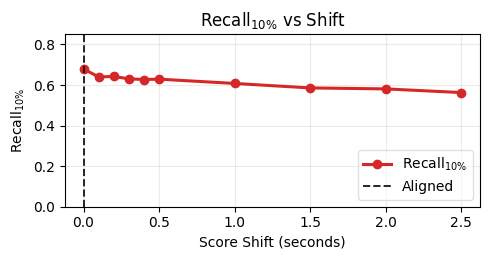

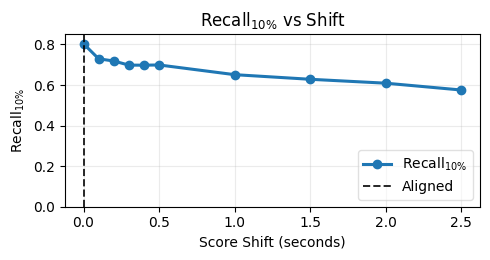

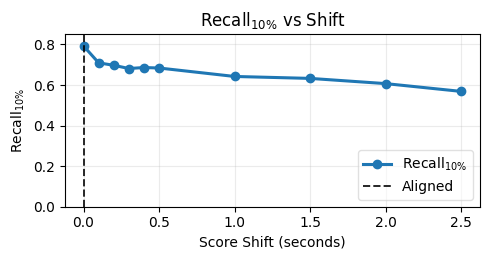

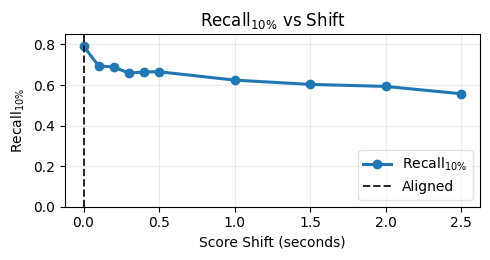

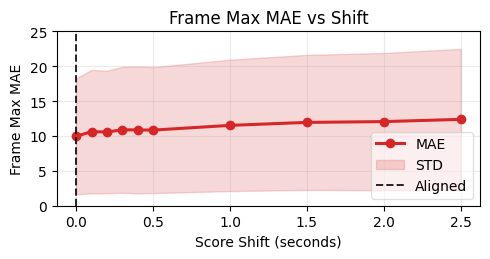

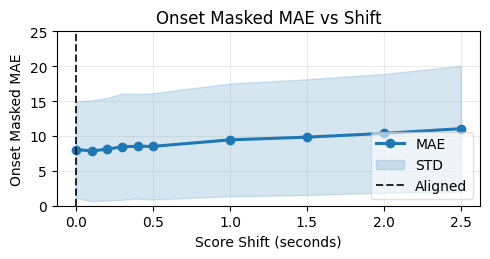

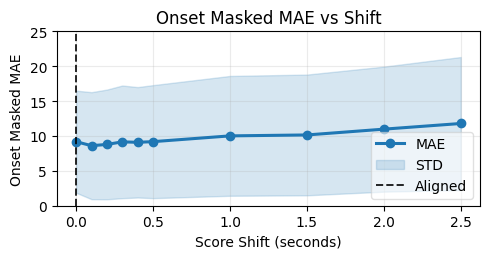

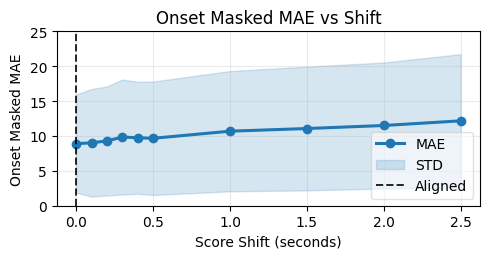

In [18]:
import sys
sys.path.insert(0, "/media/datadisk/home/22828187/zhanh/202601_midisemi/score_hpt/pytorch")
import importlib
import pytorch.calculate_scores_unaligned as csu
importlib.reload(csu)

csv_path_film = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned_random/smd/FiLMUNetPretrained+frame/1000000_iterations/FiLMUNetPretrained+frame_smd_kim_full_random_shifted_unaligned_summary.csv"
csv_path_hpt = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned_random/smd/hpt+onset+frame+score_note_editor/20000_iterations/hpt+onset+frame+score_note_editor_smd_kim_full_random_shifted_unaligned_summary.csv"
csv_path_hppnet = "/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned_random/smd/hppnet+onset+frame+score_note_editor/20000_iterations/hppnet+onset+frame+score_note_editor_smd_kim_full_random_shifted_unaligned_summary.csv"
csv_path_dynest="/media/datadisk/home/22828187/zhanh/202510_hpt_data/workspaces/kim_eval_unaligned_random/smd/dynest+onset+frame+score_note_editor/20000_iterations/dynest+onset+frame+score_note_editor_smd_kim_full_random_shifted_unaligned_summary.csv"

csu.plot_unaligned_summary_csv(csv_path=csv_path_film,
    metric="mir_eval_recall", color="#d62728", size=(5, 2.7), y_max_axis=0.85) # #ff7f0e
csu.plot_unaligned_summary_csv(csv_path=csv_path_hpt,
    metric="mir_eval_recall", color="#1f77b4", size=(5, 2.7), y_max_axis=0.85)
csu.plot_unaligned_summary_csv(csv_path=csv_path_hppnet,
    metric="mir_eval_recall", color="#1f77b4", size=(5, 2.7), y_max_axis=0.85)
csu.plot_unaligned_summary_csv(csv_path=csv_path_dynest,
    metric="mir_eval_recall", color="#1f77b4", size=(5, 2.7), y_max_axis=0.85)

csu.plot_unaligned_summary_csv(csv_path=csv_path_film,
    metric="frame_max", color="#d62728", size=(5, 2.7), y_max_axis=25)
csu.plot_unaligned_summary_csv(csv_path=csv_path_hpt,
    metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)
csu.plot_unaligned_summary_csv(csv_path=csv_path_hppnet,
    metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)
csu.plot_unaligned_summary_csv(csv_path=csv_path_dynest,
    metric="onset_masked", color="#1f77b4", size=(5, 2.7), y_max_axis=25)
